1.Data Collection

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

ticker = "AAPL"
start = "2015-01-01"
end = datetime.now()

df = yf.download(ticker, start=start, end=end)

# Moving averages
df['DMA50'] = df['Close'].rolling(50).mean()
df['DMA200'] = df['Close'].rolling(200).mean()

# RSI
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100/(1+rs))

# MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2

# ATR
high_low = df['High'] - df['Low']
high_close = abs(df['High'] - df['Close'].shift())
low_close = abs(df['Low'] - df['Close'].shift())

tr = pd.concat([high_low, high_close, low_close], axis=1)
tr = tr.max(axis=1)

df['ATR'] = tr.rolling(14).mean()

print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(2808, 10)


Price,Close,High,Low,Open,Volume,DMA50,DMA200,RSI,MACD,ATR
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2015-01-02,24.214897,24.682230,23.776357,24.671155,212818400,NaN,NaN,NaN,0.000000,NaN
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000,NaN,NaN,NaN,-0.054418,NaN
2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400,NaN,NaN,NaN,-0.096257,NaN
2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600,NaN,NaN,NaN,-0.101615,NaN
2015-01-08,24.781895,24.839481,24.075359,24.192747,237458000,NaN,NaN,NaN,-0.031507,NaN


2. DATA EXPLORATION AND VISUALIZATION



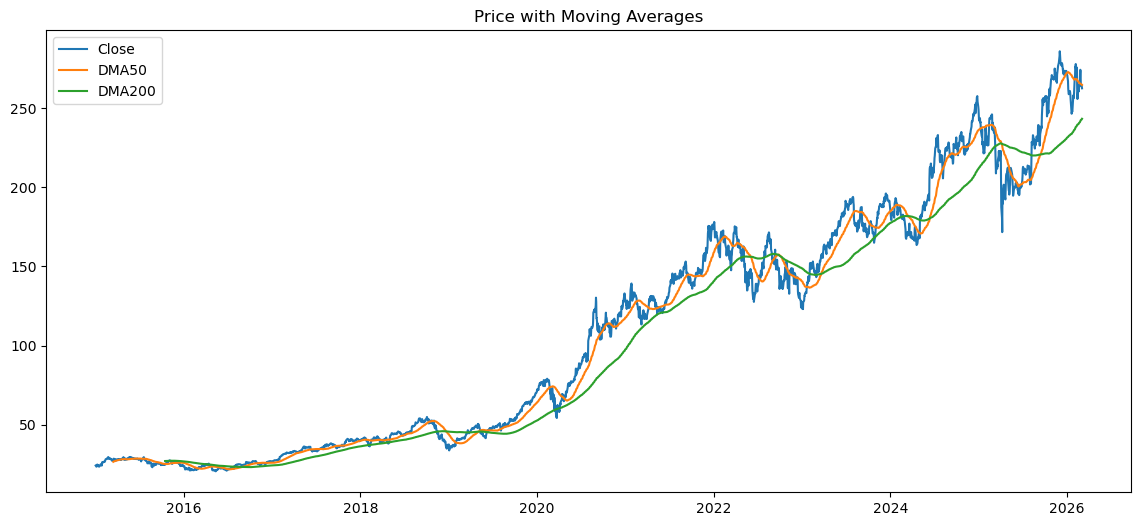

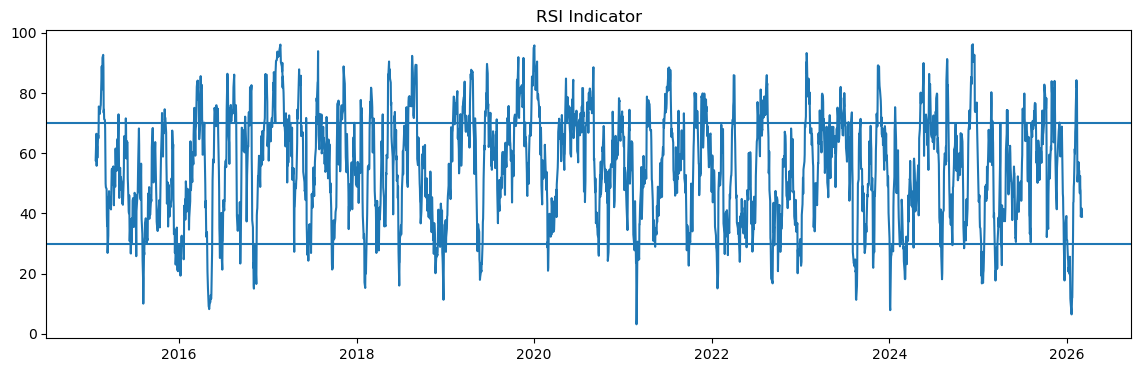

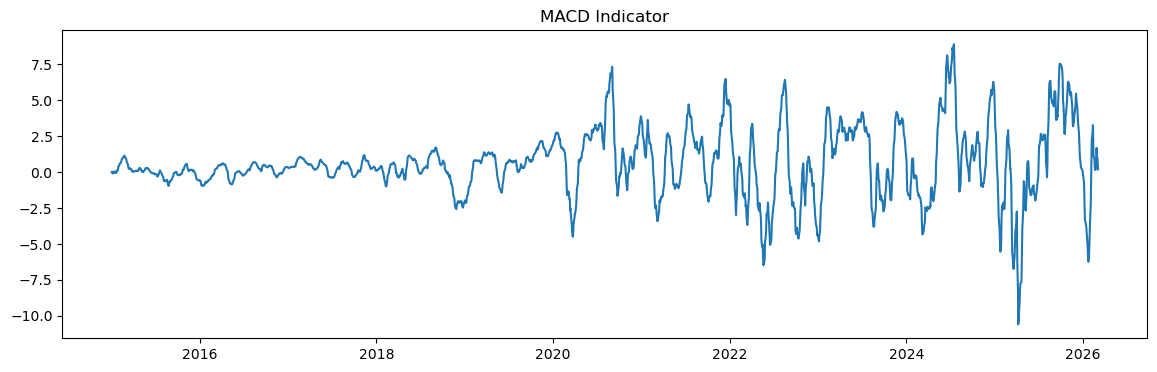

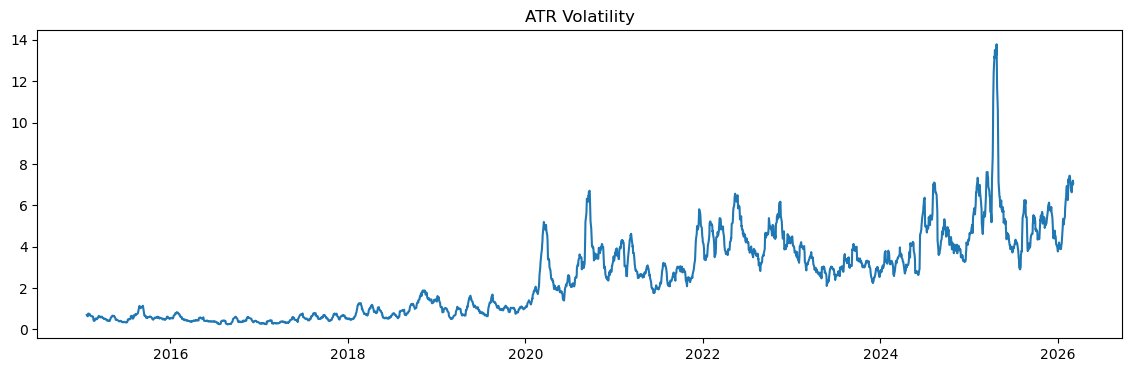

In [5]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label="Close")
plt.plot(df.index, df['DMA50'], label="DMA50")
plt.plot(df.index, df['DMA200'], label="DMA200")
plt.legend()
plt.title("Price with Moving Averages")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(df.index, df['RSI'])
plt.axhline(70)
plt.axhline(30)
plt.title("RSI Indicator")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(df.index, df['MACD'])
plt.title("MACD Indicator")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(df.index, df['ATR'])
plt.title("ATR Volatility")
plt.show()

3. FEATURE ENGINEERING

Training shape: (2086, 7)
Testing shape: (522, 7)


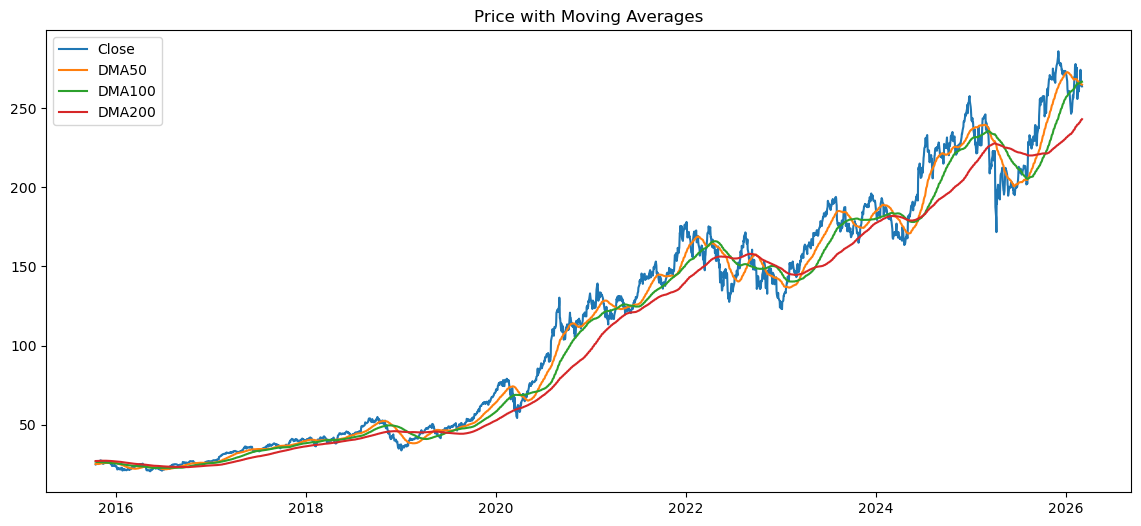

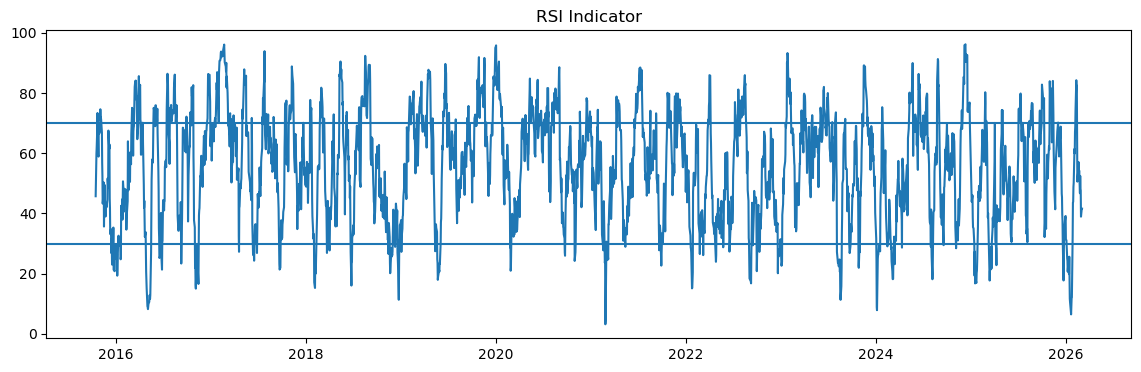

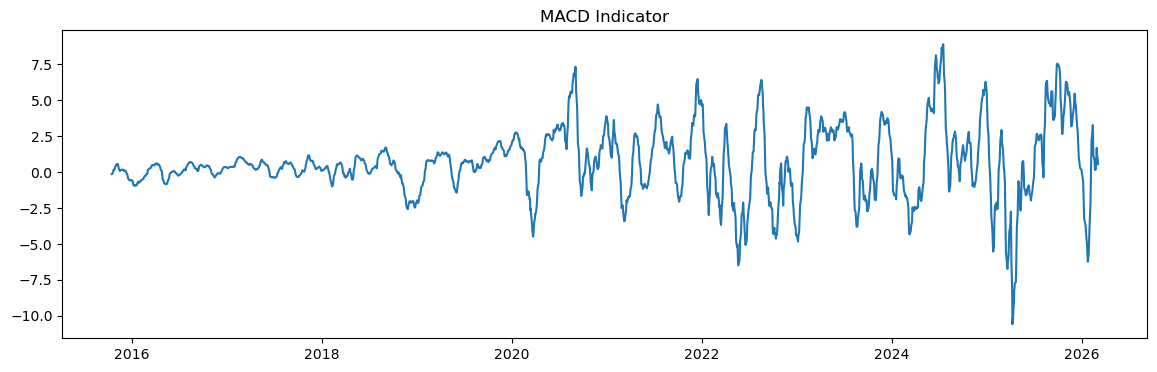

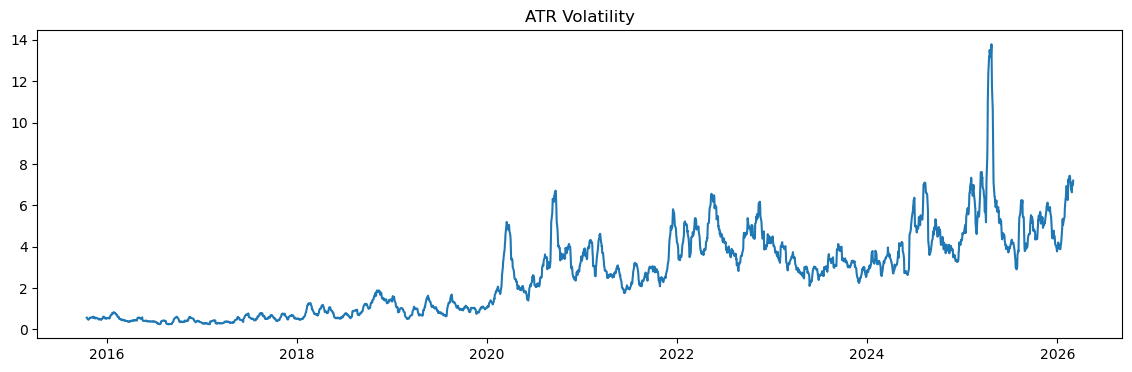

In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# FIX MULTIINDEX COLUMN ISSUE
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# INDICATORS
df['DMA50'] = df['Close'].rolling(50).mean()
df['DMA100'] = df['Close'].rolling(100).mean()
df['DMA200'] = df['Close'].rolling(200).mean()

delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100/(1+rs))

exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2

high_low = df['High'] - df['Low']
high_close = abs(df['High'] - df['Close'].shift())
low_close = abs(df['Low'] - df['Close'].shift())
tr = pd.concat([high_low, high_close, low_close], axis=1)
tr = tr.max(axis=1)

df['ATR'] = tr.rolling(14).mean()

# TARGET
df['Target'] = df['Close'].shift(-1)

# FEATURES
features = [
'Close',
'DMA50',
'DMA100',
'DMA200',
'RSI',
'MACD',
'ATR'
]

df = df.dropna()

X = df[features]
y = df['Target']

# SCALING
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# MATPLOTLIB VISUALIZATION
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label="Close")
plt.plot(df.index, df['DMA50'], label="DMA50")
plt.plot(df.index, df['DMA100'], label="DMA100")
plt.plot(df.index, df['DMA200'], label="DMA200")
plt.title("Price with Moving Averages")
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(df.index, df['RSI'])
plt.axhline(70)
plt.axhline(30)
plt.title("RSI Indicator")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(df.index, df['MACD'])
plt.title("MACD Indicator")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(df.index, df['ATR'])
plt.title("ATR Volatility")
plt.show()

4.DATA PREPROCESSING

In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# FIX yfinance MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# CREATE TARGET
df['Target'] = df['Close'].shift(-1)

# SELECT FEATURES
features = [
    'Close',
    'DMA50',
    'DMA100',
    'DMA200',
    'RSI',
    'MACD',
    'ATR'
]

# REMOVE NaN VALUES
df = df.dropna(subset=features + ['Target'])

# FEATURES & TARGET
X = df[features]
y = df['Target']

# SCALE FEATURES
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# TRAIN TEST SPLIT (TIME SERIES SAFE)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    shuffle=False
)

print("Clean dataset shape:", df.shape)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Clean dataset shape: (2607, 12)
Training shape: (2085, 7)
Testing shape: (522, 7)


5.SEQUENCE CREATION

In [8]:


import numpy as np

def create_sequences(X, y, time_steps=60):
    Xs = []
    ys = []
    
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y.iloc[i + time_steps])
        
    return np.array(Xs), np.array(ys)

TIME_STEPS = 60

X_train_seq, y_train_seq = create_sequences(
    X_train,
    y_train,
    TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test,
    y_test,
    TIME_STEPS
)

print("Train sequence shape:", X_train_seq.shape)
print("Test sequence shape:", X_test_seq.shape)

Train sequence shape: (2025, 60, 7)
Test sequence shape: (462, 60, 7)


6.BUILDIN ML MODEL

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

C:\Users\shike\.conda\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,569 (209.25 KB)

 Trainable params: 53,569 (209.25 KB)

 Non-trainable params: 0 (0.00 B)

7.MODEL TRAINING

In [10]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - loss: 6389.5796 - val_loss: 19059.5723
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 2929.9709 - val_loss: 10847.4258
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 2522.9058 - val_loss: 10410.2393
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 2531.3967 - val_loss: 10457.7158
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2519.8157 - val_loss: 10307.4229
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2514.6665 - val_loss: 10174.2744
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 2508.1233 - val_loss: 10050.7939
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 2500.1123 - val_loss: 10604.0996
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 1926.6106 - val_loss: 5138.2158
Epoch 10/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 288.3694 - val_loss: 1465.0222
Epoch 11/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 132.2826 - val_loss: 

8.PREPARING TEST DATA

In [11]:
X_test_final = X_test_seq
y_test_final = y_test_seq

print(X_test_final.shape)

(462, 60, 7)


9.MAKE PREDICTION

In [12]:
predictions = model.predict(X_test_final)

print(predictions.shape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
(462, 1)


10.MODEL EVALUATION

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

rmse = np.sqrt(mean_squared_error(y_test_final, predictions))
mae = mean_absolute_error(y_test_final, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 72.72139588353589
MAE: 68.11818060936866


11. ACTUAL VS PLOT 

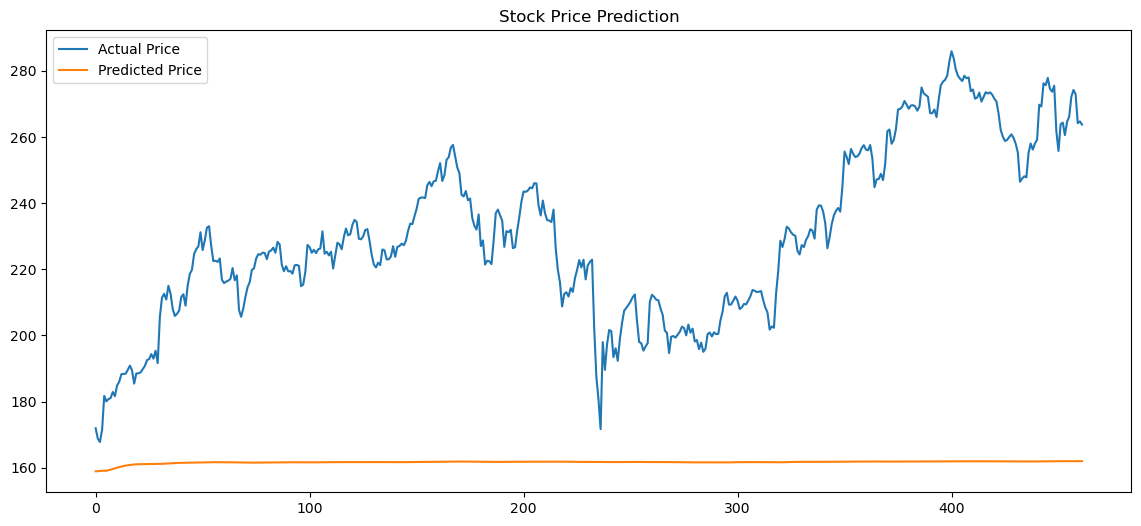

In [14]:
plt.figure(figsize=(14,6))

plt.plot(y_test_final, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("Stock Price Prediction")
plt.legend()
plt.show()